# Exercise 2

The goal of the exercise is to implement the MPPI algorithm discussed in class to control a (simplified) 3 degrees of freedom manipulator.

You do not have access to the dynamics of the manipulator but only to a simulator (the ``simulate`` function) which you can use to test how the manipulator would behave for a given control sequence.
* The states $x$ of the manipulator are the angles (in radians) of the 3 joints.
* The controls $u$ set the velocity of the joints (3 controls).
* The tip of the manipulator is $p(x)$ and depends on the current states $x$ (this is computed using a ``forward_kinematics`` function).
* We assume a single shooting problem where we only optimize the control sequence $\bar{u} = u_0,u_1,\cdots$ and compute the resulting states using the simulator

The goal is to get the manipulator's tip $p(x)$ to reach a desired goal position by minimizing (with respect to $\bar{u}$)
$$l(\bar{u}) = \sum_{n=0}^{N_{horizon}} (p(x_n) - p_{desired})^2 + 0.01 u_n^2$$

To do so, you will implement a model-predictive controller using the MPPI algorithm in its inner loop.

## MPPI algorithm
At each iteration, the MPPI algorithm computes an improved control through
$$\bar{u} \leftarrow \bar{u} - \alpha \frac{ - \lambda \mathbb E \left[  \exp\left(- \frac{1}{\lambda} l(\bar{u} + \mu \epsilon) \right) \Sigma^{-1}  \epsilon \right]}{ \mu \mathbb   E \left[ \exp\left(- \frac{1}{\lambda} l(\bar{u} + \mu \epsilon) \right) \right]  }$$

which is approximated through Monte-Carlo sampling by
$$\bar{u} \leftarrow \bar{u} - \alpha \frac{ - \lambda \mathbb \sum_{k=1}^K \left(\exp\left(- \frac{1}{\lambda} l(\bar{u} + \mu \epsilon_k) \right) \Sigma^{-1}  \epsilon_k \right)}{ \mu \mathbb   \sum_{k=1}^K \left( \exp\left(- \frac{1}{\lambda} l(\bar{u} + \mu \epsilon_k) \right) \right)  }$$


Tips to implement the algorithm:
* The parameters $\alpha = 1$, $\Sigma = I$, $\lambda=0.1$, $\mu=2$ and $K=50$ work well for this problem (use the same samples to evaluate both sums)
* Do only one update of $\bar{u}$ per control cycle (i.e. one descent step) and reuse the previous trajectory as an initial guess shifted by one time-step (for the warm start)
* Use $N_{horizon} = 10$ (optimize 10 time steps ahead)
* Use the numpy function ``random.multivariate_normal`` to draw a random sample from a multi-dimensional Gaussian distribution (you will need to draw $3N_{horizon}$ samples for $\epsilon$)

## Questions
1. Implement the MPPI algorithm and use it to reach the following positions $(2,1)$, $(2,2)$, $(1,-2)$ (one full run per position). Run the simulation for 500 time steps.
2. How does the algorithm perform across different runs? Do you always get the same result? Why?
3. Plot the average cost and its variance across 10 runs for each target position

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import manipulator

In [8]:
## the manipulator package contains all the necessary functions to simulate the robot

## the forward_kinematics function returns the position of the tip of the manipulator as a function of the joint positions
joint_position = np.array([0.,0.,0.])
tip_position = manipulator.forward_kinematics(joint_position)
print(f'the tip of the manipulator is at x={tip_position[0]:0.1f}, y={tip_position[1]:0.1f} ' + \
      f'when the joints are at {joint_position[0]:0.1f}, {joint_position[2]:0.1f}, {joint_position[2]:0.1f}')

joint_position = np.array([0.5,0.5,0.5])
tip_position = manipulator.forward_kinematics(joint_position)
print(f'the tip of the manipulator is at x={tip_position[0]:0.1f}, y={tip_position[1]:0.1f} ' + \
      f'when the joints are at {joint_position[0]:0.1f}, {joint_position[2]:0.1f}, {joint_position[2]:0.1f}')

the tip of the manipulator is at x=2.4, y=0.0 when the joints are at 0.0, 0.0, 0.0
the tip of the manipulator is at x=1.4, y=1.8 when the joints are at 0.5, 0.5, 0.5


In [9]:
## the manipulator can be simulated with a control trajectory of length N

## the simulate function returns the time, state trajectory [3,N] and control trajectory [3,N]

N = 500 #number of timesteps
initial_state = np.array([0.,0.,0.])

## we compute a random control trajectory drawn from a multivariate normal distribution
u = np.reshape(np.random.multivariate_normal(np.zeros(3*N), np.eye(3*N)),[3,N])
t,x, u = manipulator.simulate(initial_state, u, N)

## the states can be displayed using the animate_robot function as follows
manipulator.animate_robot(x)

Your browser does not support the video tag.

In [ ]:
u=np.zeros([3,10])
pd=np.array([2,2])
def controller(states,Nhorizon=10,samples=50,alpha=1,lamb=.1,mu=2):
    ''' simplistic MPC loop '''
    global pd,u,costs

    #time shift
    u[:,:-1]=u[:,1:] 
    u[:,-1]=0
    all_costs = np.zeros(samples)
    all_perturbations = np.zeros((samples, 3, Nhorizon))
    for i in range(samples):
        ep = np.reshape(np.random.multivariate_normal(np.zeros(3*Nhorizon), np.eye(3*Nhorizon)),[3,Nhorizon])
        # ep = np.random.randn(3, Nhorizon) #faster for simple variance
        u_guess = u+mu*ep
        t, st, control = manipulator.simulate(states,u_guess , Nhorizon)
        # print(st.shape)
        l=lambda x: np.sum(np.square(manipulator.forward_kinematics(x)-pd))
        la= np.sum(np.apply_along_axis(l, axis=0, arr=st))
        
        
        l= la+0.01*np.sum(np.square(u_guess))
        all_costs[i] = l
        all_perturbations[i] = ep
        # print(la,l-la)
        # if np.isnan(l)
            # print(l,la)
        
        # exp =  np.exp((-1/lamb)*l)
        # # print(np.sum(np.square(u_guess)).shape,la.shape)
        # # print(exp)
        # num+=-lamb*exp*ep
        # den+=mu*exp +1e-25 #added to avoid zero divide
    min_cost = np.min(all_costs)
    # vars.append(np.var(all_costs))
    costs.append(np.mean(all_costs))
    # Stabalising because values very mall.
    stable_costs = all_costs - min_cost  #
    exp_weights = np.exp((-1 / lamb) * stable_costs) 
    sum_weights = np.sum(exp_weights) + 1e-25  # Avoiding zero divide #denom
    weights = exp_weights / sum_weights
    delta_u = -1*(lamb/mu)* np.sum(weights[:, np.newaxis, np.newaxis] * all_perturbations, axis=0)
   
    u = u - alpha* delta_u#num/den #
    
    
    # u[:,-1] =u[:,-2]
    return u[:,0]

In [21]:
def plot_everything(C,V):
    ex=np.array(C)
    ef=np.array(V).reshape(-1,1) #[:, np.newaxis]
   

    iterations = np.arange(len(ef)) 
    plt.figure(1,figsize=(15, 6))
    plt.plot(iterations, ex, marker='o', linestyle='-',markersize=3)
    plt.title('Average Costs across Runs')
    plt.xlabel('Runs')
    plt.ylabel('Cost')
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.figure(2,figsize=(15, 6)) # Create a new figure for the second plot
    c=['r','g','b','x']
    # ax = plt.subplot(111)
    plt.plot(iterations, ef, marker='s', linestyle='--',markersize=3)
    # ax.legend(loc='upper right', fontsize='medium')
    plt.title('Variance of Costs Across Runs')
    plt.xlabel('Runs')
    plt.ylabel('Variance')
    plt.grid(True, which='both', linestyle='--', linewidth=0.5) 

In [49]:
Cruns=[]
Vruns=[]

10 iterations of (2,1) - animating the final run

In [50]:
u=np.zeros((3, 10))  
pd=np.array([2,1]) #TARGET
C=[]
s=None
for i in range(10):
    costs=[]
    N_timesteps = 500
    t, states, control = manipulator.simulate(np.zeros([3,]), controller, N_timesteps)
    s=states
    
    ## display the results
    l=lambda x: np.sum(np.square(manipulator.forward_kinematics(x)-pd))
    la= np.sum(np.apply_along_axis(l, axis=0, arr=states))
    l= la+0.01*np.sum(np.square(control))
    C.append(l)
Cruns.append(np.mean(C))
Vruns.append(np.var(C))
manipulator.animate_robot(s)

## Note that the simulate function can take either a control trajectory of size [3,N] 
## or a function f(states) that will be called at each control cycle (cf. examples above)

Your browser does not support the video tag.

10 iterations of target 2,2

In [51]:
u=np.zeros((3, 10))  
pd=np.array([2,2]) #TARGET
C=[]
s=None
for i in range(10):
    costs=[]
    N_timesteps = 500
    t, states, control = manipulator.simulate(np.zeros([3,]), controller, N_timesteps)
    s=states
    
    ## display the results
    l=lambda x: np.sum(np.square(manipulator.forward_kinematics(x)-pd))
    la= np.sum(np.apply_along_axis(l, axis=0, arr=states))
    l= la+0.01*np.sum(np.square(control))
    C.append(l)
Cruns.append(np.mean(C))
Vruns.append(np.var(C))
manipulator.animate_robot(s)

## Note that the simulate function can take either a control trajectory of size [3,N] 
## or a function f(states) that will be called at each control cycle (cf. examples above)

Your browser does not support the video tag.

10 iterations of target 1,-2

In [52]:
u=np.zeros((3, 10))  
pd=np.array([1,-2]) #TARGET
C=[]
s=None
for i in range(10):
    costs=[]
    N_timesteps = 500
    t, states, control = manipulator.simulate(np.zeros([3,]), controller, N_timesteps)
    s=states
    
    ## display the results
    l=lambda x: np.sum(np.square(manipulator.forward_kinematics(x)-pd))
    la= np.sum(np.apply_along_axis(l, axis=0, arr=states))
    l= la+0.01*np.sum(np.square(control))
    C.append(l)
Cruns.append(np.mean(C))
Vruns.append(np.var(C))
manipulator.animate_robot(s)

## Note that the simulate function can take either a control trajectory of size [3,N] 
## or a function f(states) that will be called at each control cycle (cf. examples above)

Your browser does not support the video tag.

### 2. The algorithm performs reasonably well across different runs, and the costs converge to a fixed neighbourhood of values. The slight variations in how the manipulator gets to this position is due to the stocastic nature of the MMPI Gradient calculation process. We also notice increasing variance in costs, the further along the horizon we want to travel

### 3. SUMMARY: PLOTTING AVERAGE COSTS AND VARIANCE ACROSS RUNS Note: My initial costs are zeros

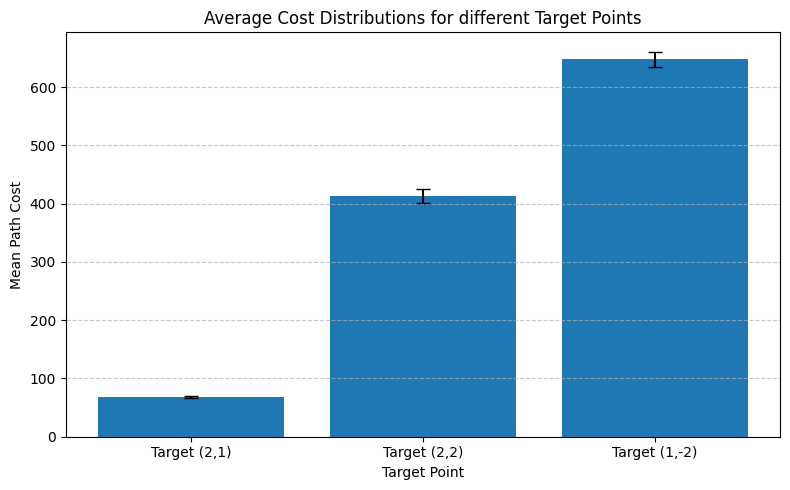

In [54]:
std_dev = np.sqrt(np.array(Vruns))

x_pos = np.arange(len(Cruns))

# 5. Create the bar plot
plt.figure(figsize=(8, 5))
plt.bar(x_pos, Cruns, yerr=std_dev, capsize=5)
plt.xlabel("Target Point")
plt.ylabel("Mean Path Cost")
plt.title("Average Cost Distributions for different Target Points")
plt.xticks(x_pos, ["Target (2,1)", "Target (2,2)", "Target (1,-2)"])

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() 